# Données de la Banque mondiale

`WorldBank` enveloppe la bibliothèque `wbdata` : recherche de sources et
d'indicateurs, puis téléchargement des séries dans un `DataFrame` pandas.

- `get_sources()` — catalogue des bases de données
- `get_indicators(source=...)` — indicateurs d'une source
- `get_countries(query=...)` — codes pays
- `get_data(indicators, country=..., date=...)` — les valeurs

Un indicateur se désigne par son code (ex. `NY.GDP.PCAP.CD` = PIB par
habitant, $ courants). `indicators` est un `dict {code: nom_de_colonne}`.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

import pandas as pd
import cartograpy as cp
from cartograpy.data import WorldBank

wb = WorldBank()

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


## Explorer le catalogue

Les sources (`World Development Indicators` = source 1, la plus courante).

In [2]:
sources = pd.DataFrame(wb.get_sources())[["id", "name"]]
sources.head(12)

,id,name
0,1,Doing Business
1,2,World Development Indicators
2,3,Worldwide Governance Indicators
3,5,Subnational Malnutrition Database
4,6,International Debt Statistics
5,11,Africa Development Indicators
6,12,Education Statistics
7,13,Enterprise Surveys
8,14,Gender Statistics
9,15,Global Economic Monitor


In [3]:
# Chercher un indicateur par mot-clé (via wbdata directement pour le filtre `query`)
import wbdata

hits = wbdata.get_indicators(query="GDP per capita")
[(i["id"], i["name"]) for i in hits[:8]]

[('6.0.GDPpc_constant',
  'GDP per capita, PPP (constant 2011 international $) '),
 ('CC.GHG.MEMG.GC',
  'Macro drivers of GHG emissions growth in the period 2012-2018 - GDP per capita'),
 ('FB.DPT.INSU.PC.ZS', 'Deposit insurance coverage (% of GDP per capita)'),
 ('NV.AGR.PCAP.KD.ZG', 'Real agricultural GDP per capita growth rate (%)'),
 ('NY.GDP.PCAP.CD', 'GDP per capita (current US$)'),
 ('NY.GDP.PCAP.CN', 'GDP per capita (current LCU)'),
 ('NY.GDP.PCAP.KD', 'GDP per capita (constant 2015 US$)'),
 ('NY.GDP.PCAP.KD.ZG', 'GDP per capita growth (annual %)')]

In [4]:
# Retrouver des codes pays
[(c["id"], c["name"]) for c in wb.get_countries(query="ivoire")]

[('CIV', "Cote d'Ivoire")]

## Une valeur, une année, tous les pays

In [5]:
pib = wb.get_data({"NY.GDP.PCAP.CD": "pib_hab"}, date="2022")
pib = pib.dropna().sort_values("pib_hab", ascending=False)
pib.head(10)

,pib_hab
country,
Monaco,226052.060665
Liechtenstein,188055.003235
Luxembourg,123719.658916
Bermuda,119969.173269
Norway,113122.130766
Ireland,105190.685953
Switzerland,97809.095567
Cayman Islands,92937.883832
Singapore,91227.697043


## Plusieurs pays, une période → série temporelle

`date` accepte une année (`"2022"`) ou un couple `("2000", "2022")`.
`parse_dates=True` renvoie un index de dates exploitable directement.

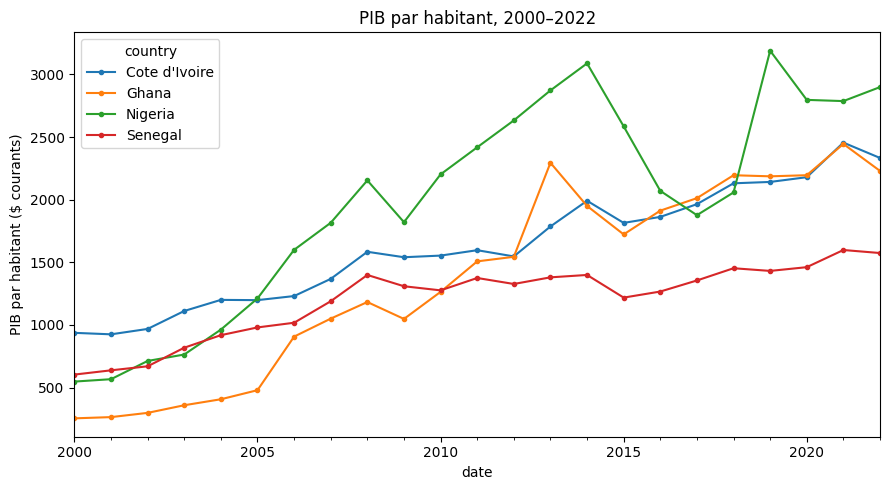

In [6]:
serie = wb.get_data(
    {"NY.GDP.PCAP.CD": "pib_hab"},
    country=["CIV", "GHA", "SEN", "NGA"],
    date=("2000", "2022"),
    parse_dates=True,
)
large = serie.reset_index().pivot(index="date", columns="country", values="pib_hab")

ax = large.plot(figsize=(9, 5), marker="o", ms=3)
ax.set_ylabel("PIB par habitant ($ courants)")
ax.set_title("PIB par habitant, 2000–2022")
ax.figure.tight_layout()

## Plusieurs indicateurs en un appel

In [7]:
multi = wb.get_data(
    {
        "SP.POP.TOTL": "population",
        "NY.GDP.PCAP.CD": "pib_hab",
        "SP.DYN.LE00.IN": "esperance_vie",
    },
    country=["CIV", "GHA", "SEN", "NGA", "MLI"],
    date="2022",
)
multi

,population,pib_hab,esperance_vie
country,,,
Cote d'Ivoire,30395002.0,2333.371283,61.562
Ghana,33149152.0,2229.891227,65.246
Mali,23072640.0,976.914116,60.035
Nigeria,223150896.0,2899.160475,54.079
Senegal,17651103.0,1574.028106,67.788


## Joindre à des frontières → carte choroplèthe

L'index du `DataFrame` est le **nom** du pays. On le convertit en code ISO3
avec `get_countries()`, puis on fusionne avec les géométries de `Bound`.

In [8]:
from cartograpy.data import Bound

# valeurs
df = wb.get_data({"SP.DYN.LE00.IN": "esperance_vie"}, date="2022").reset_index()

# nom de pays -> ISO3 (on exclut les agrégats régionaux)
pays_meta = wbdata.get_countries()
nom_vers_iso3 = {
    c["name"]: c["id"]
    for c in pays_meta
    if c["region"]["value"] != "Aggregates"
}
df["iso3"] = df["country"].map(nom_vers_iso3)
df = df.dropna(subset=["iso3", "esperance_vie"])

# géométries : pays d'Afrique
monde = Bound().get_world("country")
afrique = monde[monde["continent"] == "Africa"]
gdf = afrique.merge(df[["iso3", "esperance_vie"]], on="iso3", how="inner")
print(len(gdf), "pays joints")

49 pays joints


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-44.95, 78.46, -39.87, 42.40]


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-44.95, 78.46, -39.87, 42.40]


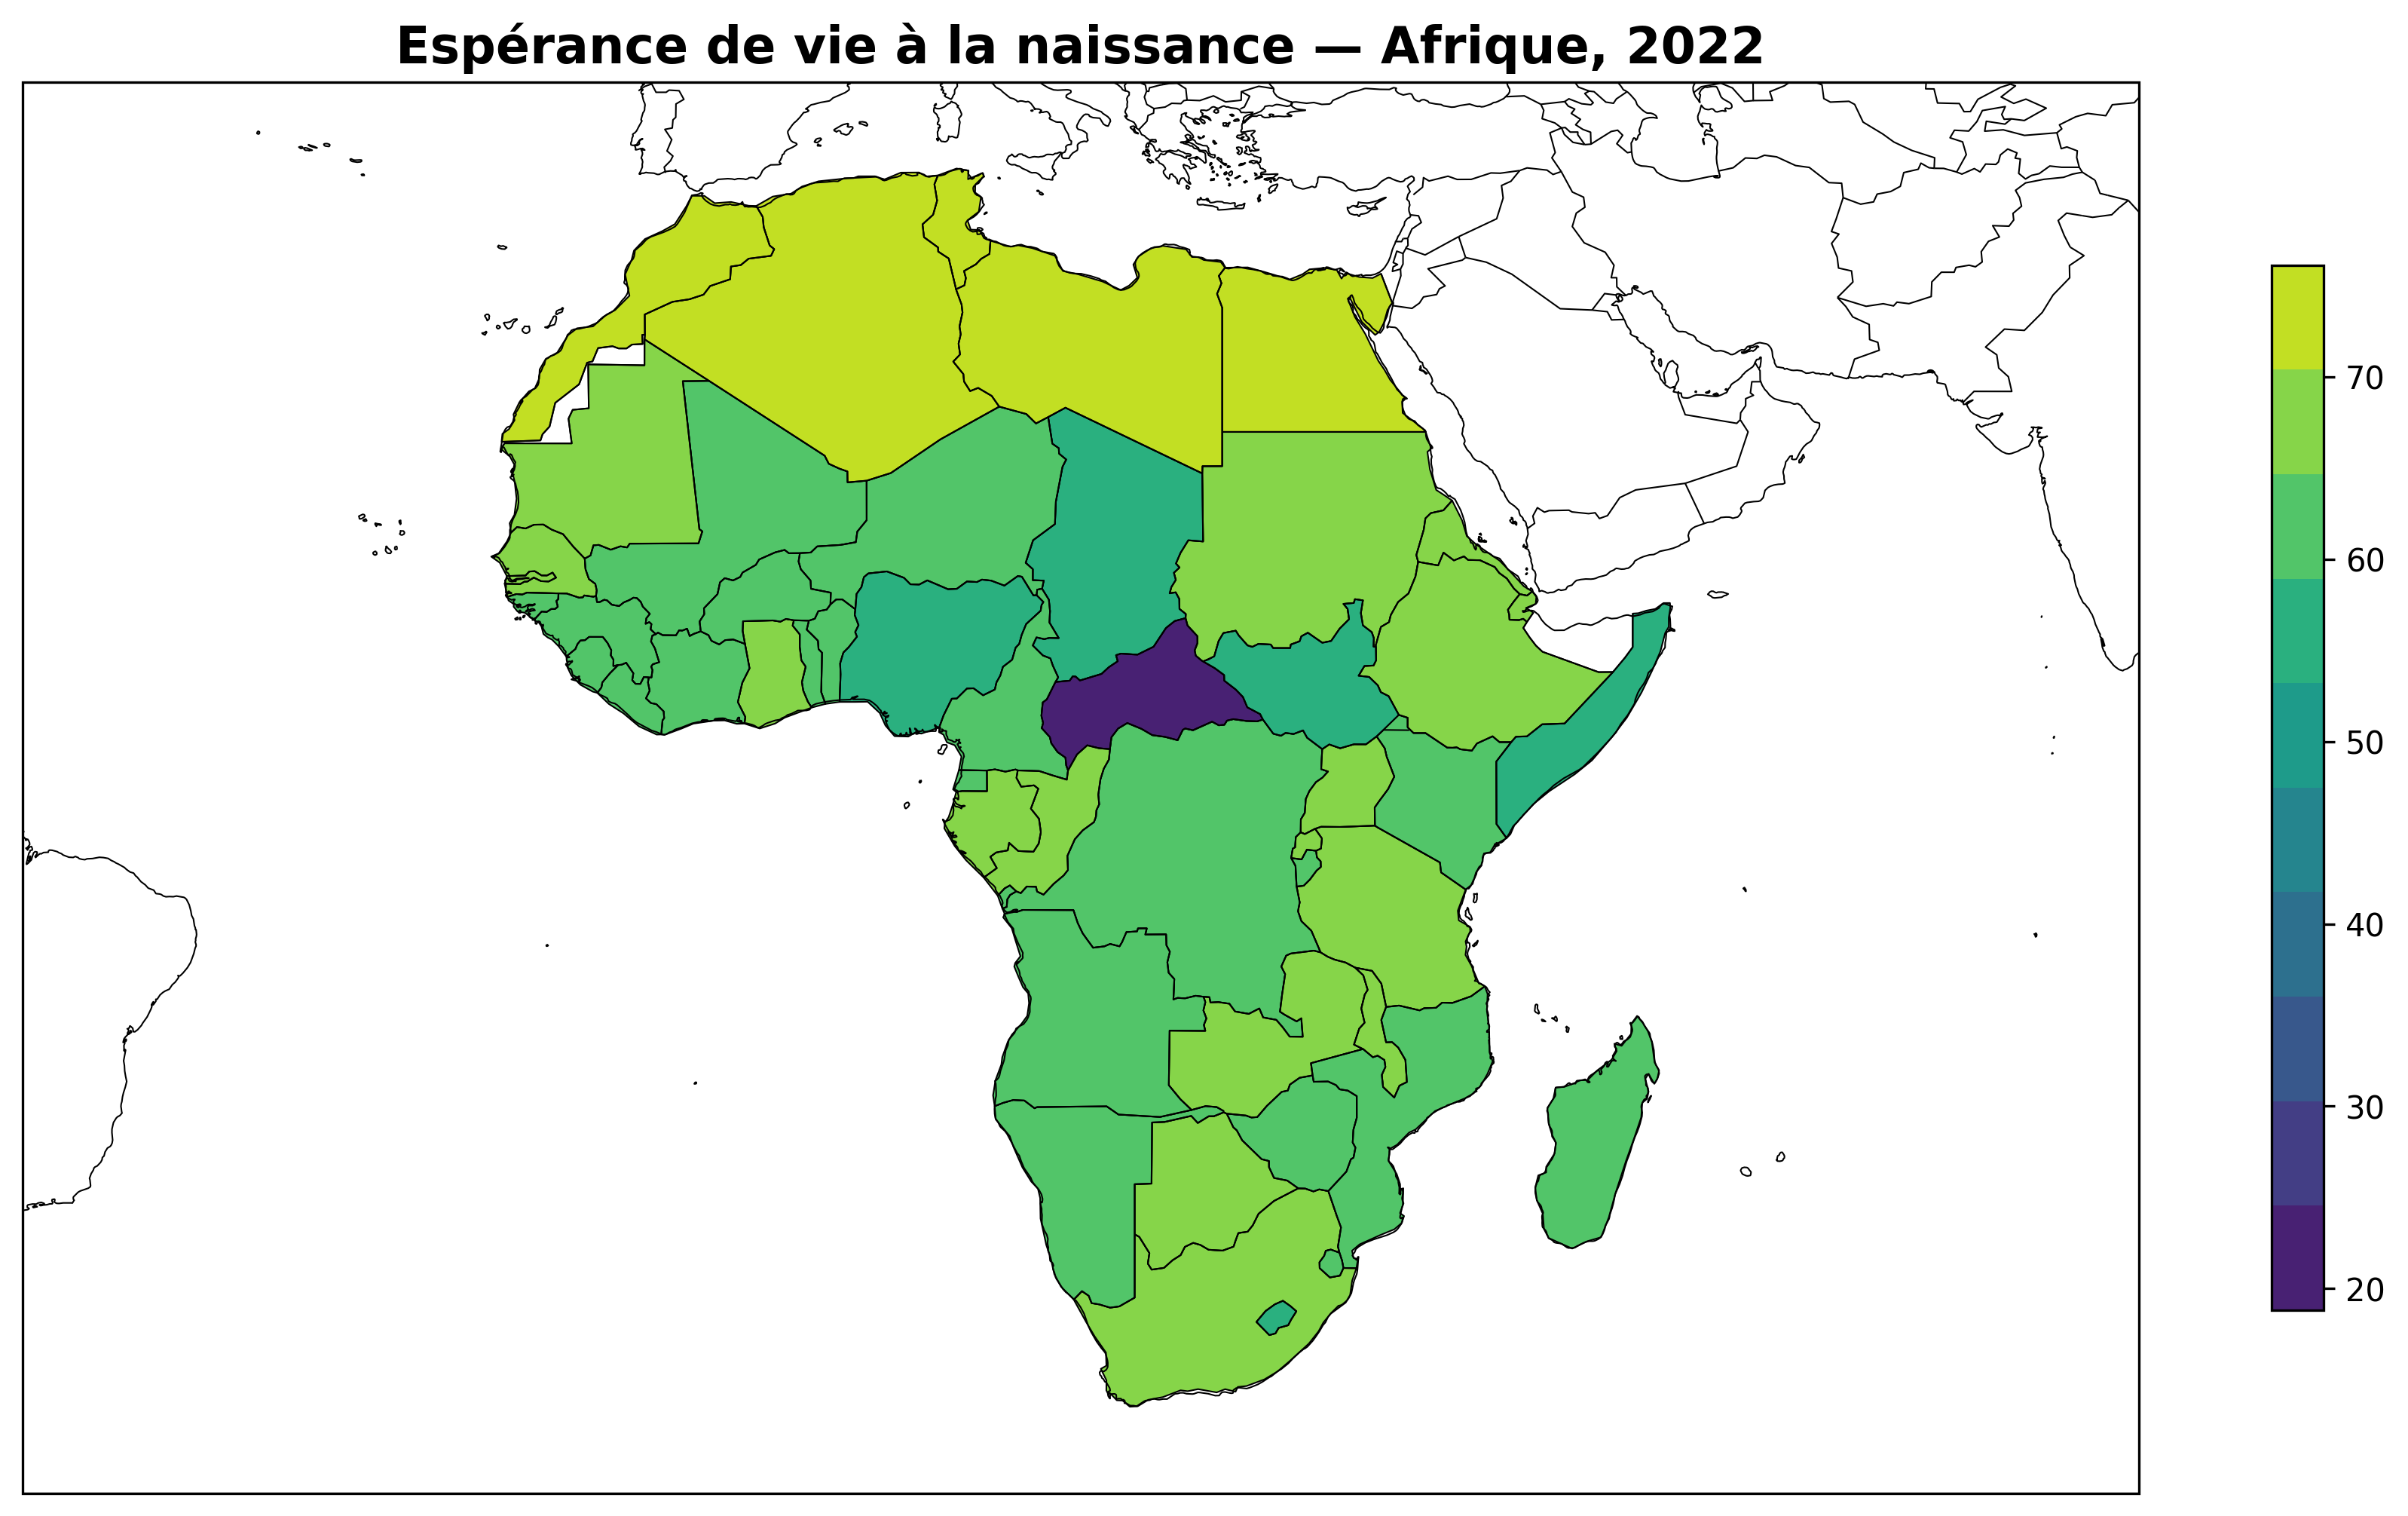

In [9]:
m = cp.Map(title="Espérance de vie à la naissance — Afrique, 2022")
m.add_polygons_choropleth(
    gdf,
    column_to_plot="esperance_vie",
    cmap="viridis",
    show_labels=False,
)
m.show()